In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import random
import matplotlib.pyplot as plt
from skimage.util import random_noise
from tensorflow.keras.layers import Layer, Conv2D, Add, ReLU, Concatenate, GlobalAveragePooling2D, Multiply, Input, Lambda,  MaxPooling2D, UpSampling2D, BatchNormalization, Dropout
from tensorflow.keras.models import Model
from keras.models import load_model
from tensorflow.keras.saving import register_keras_serializable


In [2]:

def preprocess(sample, img_size):
    """Preprocessa le immagini: ridimensionamento e normalizzazione."""
    image = tf.image.resize(sample['image'], img_size) / 255.0  # Normalizza in [0,1]
    label = sample['label']  # Estrai l'etichetta
    return image, label

def load_dataset(split, img_size=(256,256), batch_size=16):
    """
    Carica il dataset Oxford-IIIT Pet da tfds e applica il preprocessamento.
    Ritorna un dataset in batch.
    split: 'train[:80%]' 'train[80%:]' 'test'
    """

    print(split)
    dataset = tfds.load('oxford_iiit_pet', split=split, as_supervised=False)  # as_supervised=False per mantenere dict
    dataset = dataset.map(lambda sample: preprocess(sample, img_size))  # Preprocessing
    dataset = dataset.shuffle(1024).batch(batch_size).prefetch(tf.data.AUTOTUNE)  # Ottimizza il caricamento
    return dataset



In [45]:
# Parametri
img_size = (112, 112)
batch_size = 64
noise_factor = 0.3
epochs = 50

# Caricamento dataset
train_ds = load_dataset( split='train[:80%]', img_size=img_size, batch_size=batch_size)
valid_ds = load_dataset( split='train[80%:]', img_size=img_size, batch_size=batch_size)
test_ds  = load_dataset( split='test',        img_size=img_size, batch_size=batch_size)

train[:80%]
train[80%:]
test


In [167]:
"""def add_noise(x, noise_factor=0.1):
    noise = tf.random.normal(shape=tf.shape(x), mean=0.0, stddev=1.0)
    x_noisy = x + noise_factor * noise
    #x_noisy = tf.clip_by_value(x_noisy, 0.0, 0.1)
    return x_noisy"""

def add_noise_2(x, noise_factor=0.1):
    noise = tf.random.normal(shape=tf.shape(x), mean=0.0, stddev=noise_factor)
    x_noisy = x + noise
    x_noisy = tf.clip_by_value(x_noisy, 0.0, 1.0)
    return x_noisy

def add_noise(x):
    noise_levels = [0.1, 0.2, 0.3, 0.4]
    noise_factor = tf.random.shuffle(noise_levels)[0]  # scegli uno random tra i 4
    noise = tf.random.normal(shape=tf.shape(x), mean=0.0, stddev=noise_factor)
    x_noisy = x + noise
    x_noisy = tf.clip_by_value(x_noisy, 0.0, 1.0)
    return x_noisy

In [168]:
def load_dataset_with_multiple_noise_levels(split, img_size=(256,256), batch_size=16, noise_levels=[0.1, 0.2, 0.3, 0.4]):
    dataset_base = tfds.load('oxford_iiit_pet', split=split, as_supervised=False)

    # Preprocessing (resize, normalization, ecc.)
    dataset_base = dataset_base.map(lambda sample: preprocess(sample, img_size), num_parallel_calls=tf.data.AUTOTUNE)

    datasets_with_noise = []

    for nf in noise_levels:
        ds = dataset_base.map(lambda x: add_noise(nf)(x), num_parallel_calls=tf.data.AUTOTUNE)
        datasets_with_noise.append(ds)

    # Concatena tutti i dataset
    full_dataset = datasets_with_noise[0]
    for ds in datasets_with_noise[1:]:
        full_dataset = full_dataset.concatenate(ds)

    # Shuffle e batch
    full_dataset = full_dataset.shuffle(2048).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return full_dataset

In [169]:
train_ds_noisy = train_ds.map(lambda x, label: (add_noise(x), x))
valid_ds_noisy = train_ds.map(lambda x, label: (add_noise(x), x))


In [170]:
test_ds_noisy = test_ds.map(lambda x, label: add_noise(x))

In [171]:
def plot_side_by_side(x_noisy, x_original, n=10):
    """
    Visualizza n coppie di immagini affiancando l'immagine rumorosa e quella originale per immagini a colori.
    """
    plt.figure(figsize=(20, 4))
    for i in range(n):
        # Immagine rumorosa
        ax = plt.subplot(2, n, i+1)
        plt.imshow(x_noisy[i])
        plt.title("Rumorosa")
        plt.axis('off')

        # Immagine originale
        ax = plt.subplot(2, n, i+1+n)
        plt.imshow(x_original[i])
        plt.title("Originale")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

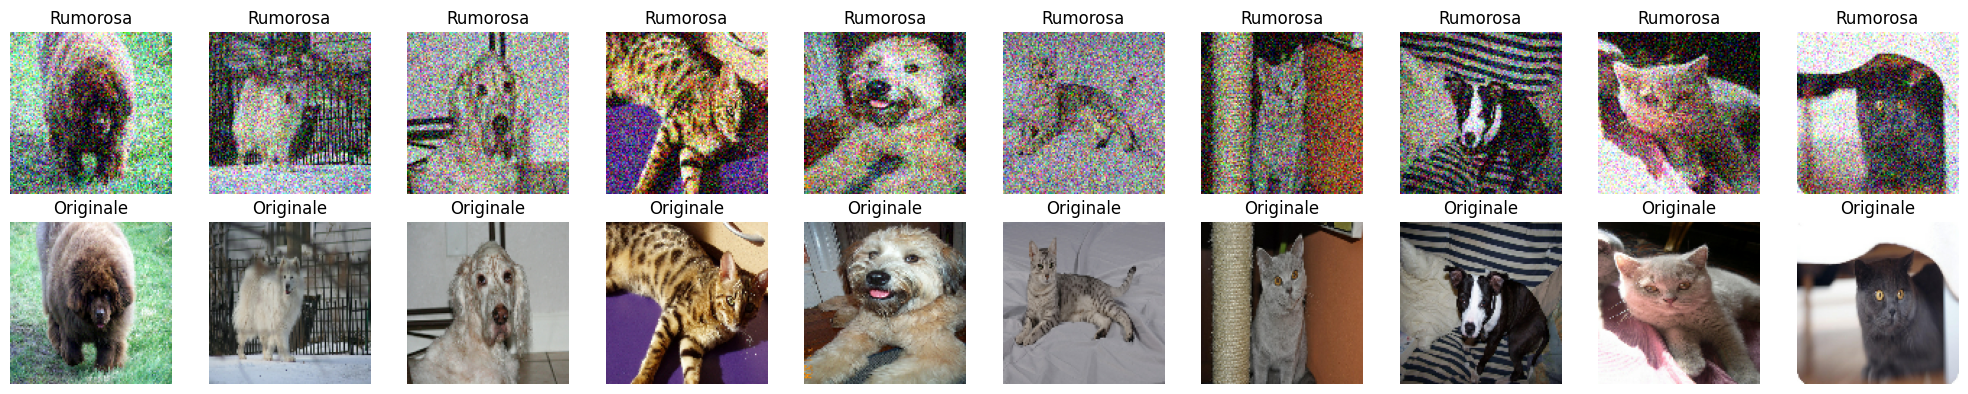

In [172]:
# Prendi un batch dal dataset (ad esempio, il primo batch)
batch = next(iter(train_ds_noisy))
x_noisy_batch, x_original_batch = batch

# Converti i tensori in array NumPy
x_noisy_np = x_noisy_batch.numpy()
x_original_np = x_original_batch.numpy()

# Usa la funzione plot_side_by_side per visualizzare n immagini
plot_side_by_side(x_noisy_np, x_original_np, n=10)


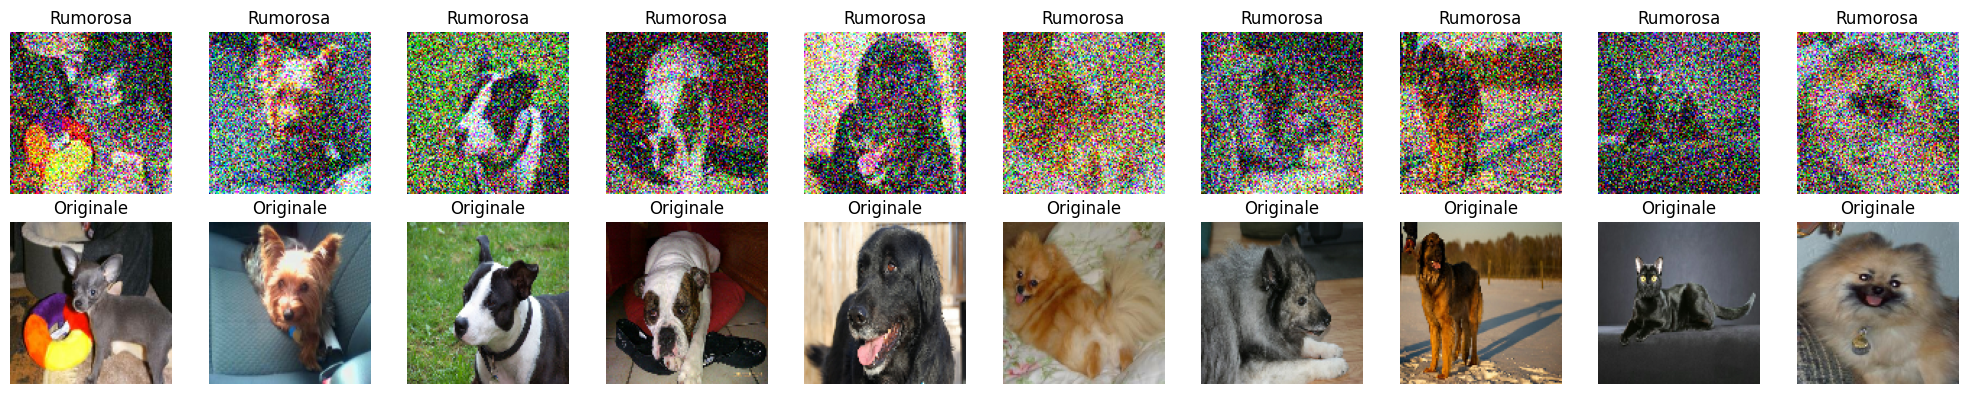

In [173]:
# Prendi un batch dal dataset (ad esempio, il primo batch)
batch = next(iter(valid_ds_noisy))
x_noisy_batch, x_original_batch = batch

# Converti i tensori in array NumPy
x_noisy_np = x_noisy_batch.numpy()
x_original_np = x_original_batch.numpy()

# Usa la funzione plot_side_by_side per visualizzare n immagini
plot_side_by_side(x_noisy_np, x_original_np, n=10)

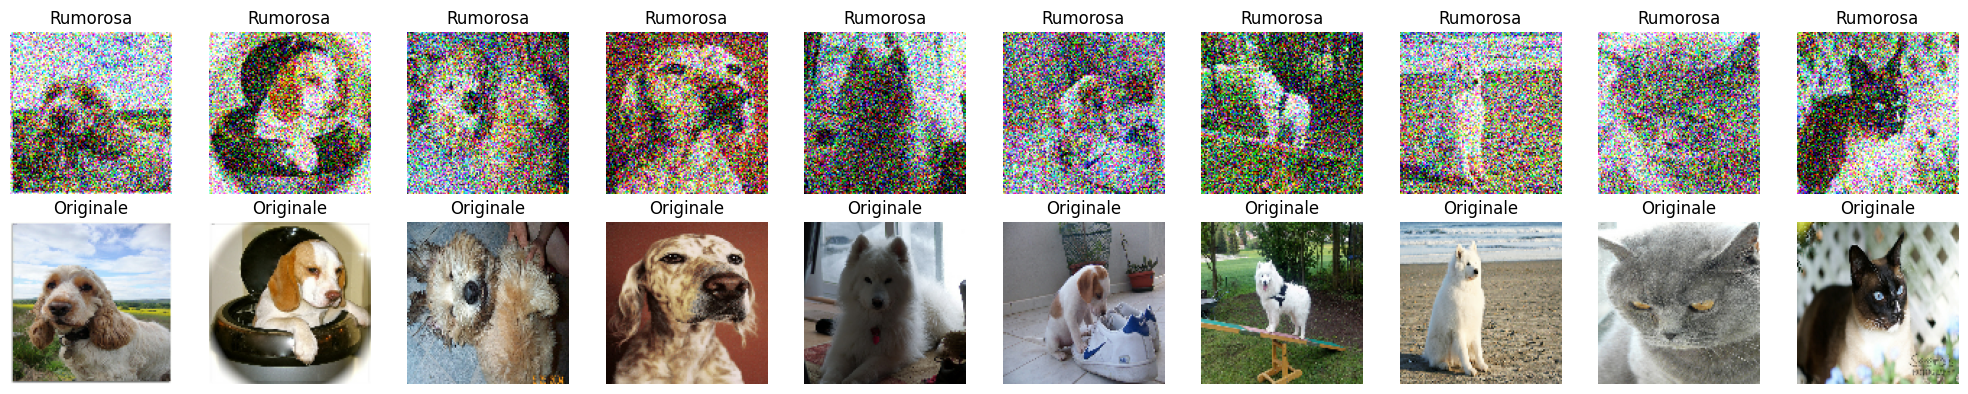

In [174]:
# Prendi un batch dal dataset (ad esempio, il primo batch)
batch = next(iter(valid_ds_noisy))
x_noisy_batch, x_original_batch = batch

# Converti i tensori in array NumPy
x_noisy_np_test = x_noisy_batch.numpy()
x_original_np_test = x_original_batch.numpy()

# Usa la funzione plot_side_by_side per visualizzare n immagini
plot_side_by_side(x_noisy_np_test, x_original_np_test, n=10)

Creazione modello

In [175]:
def plot_denoising_results(x_test_noisy, decoded_imgs, x_test, n=10):
    """
    Visualizza n immagini rumorose, le rispettive immagini denoised e quelle originali.
    """
    plt.figure(figsize=(20, 4))
    n = 10
    for i in range(n):
        # Immagine rumorosa
        ax = plt.subplot(3, n, i + 1)
        plt.imshow(x_test_noisy[i])
        plt.title("Rumorosa")
        plt.axis('off')
        # Immagine denoised
        ax = plt.subplot(3, n, i + 1 + n)
        plt.imshow(decoded_imgs[i])
        plt.title("Denoised")
        plt.axis('off')
        # Immagine originale
        ax = plt.subplot(3, n, i + 1 + 2*n)
        plt.imshow(x_test[i])
        plt.title("Originale")
        plt.axis('off')
    plt.tight_layout()
    plt.show()


In [176]:
def psnr(original, denoised):
  mse = np.mean((original - denoised) ** 2)
  if mse == 0:
    return float('inf') # immagini identiche
  max_pixel = 1.0 # valore massimo per immagini normalizzate in [0, 1]
  return 10 * np.log10((max_pixel ** 2) / mse)

In [177]:
def build_autoencoder(input_shape):
    """
    Costruisce un autoencoder convoluzionale per immagini a colori.
    Parametri:
      input_shape: forma dell'immagine in input (es. (32,32,3))
    Ritorna:
      autoencoder: modello compilato
    """
    input_img = Input(shape=input_shape)

    # Encoder
    x = Conv2D(64, (3,3), kernel_initializer="he_normal", activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2,2), padding='same')(x)
    x = Conv2D(64, (3,3), kernel_initializer="he_normal", activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2,2), padding='same')(x)

    # Decoder
    x = Conv2D(64, (3,3), kernel_initializer="he_normal", activation='relu', padding='same')(encoded)
    x = UpSampling2D((2,2))(x)
    x = Conv2D(64, (3,3), kernel_initializer="he_normal", activation='relu', padding='same')(x)
    x = UpSampling2D((2,2))(x)
    decoded = Conv2D(3, (3,3), kernel_initializer="he_normal", activation='sigmoid', padding='same')(x)

    autoencoder = Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='mse', metrics=['accuracy'])

    return autoencoder


def AutoEncoder(input_shape):
  input=Input(input_shape,name='Input')

  x=Conv2D(64, kernel_size=(3,3), kernel_initializer='he_normal', activation='relu', padding='same', name='Conv2d_1')(input)
  x=MaxPooling2D(name='Maxpool_1')(x)
  x=Conv2D(64,kernel_size=(3,3),kernel_initializer='he_normal',activation='relu',padding='same',name='Conv2d_2')(x)
  x=MaxPooling2D(name='Maxpool_2')(x)

  x=Conv2D(64,kernel_size=(3,3),kernel_initializer='he_normal',activation='relu',padding='same',name='Conv2d_3')(x)
  x=UpSampling2D(name='Upsample_1')(x)
  x=Conv2D(64,kernel_size=(3,3),kernel_initializer='he_normal',activation='relu',padding='same',name='Conv2d_4')(x)
  x=UpSampling2D(name='Upsample_2')(x)
  x=Conv2D(3,kernel_size=(3,3),kernel_initializer='he_normal',activation='relu',padding='same',name='Conv2d_5')(x)

  model=Model(input,x)
  model.compile(optimizer='adam', loss='mse', metrics=['accuracy'])

  return model

def train_autoencoder(autoencoder, x_train_noisy, x_train, x_test_noisy, x_test, epochs=50, batch_size=128):
    """
    Addestra l'autoencoder utilizzando le immagini rumorose come input e quelle originali come target.
    """
    history = autoencoder.fit(x_train_noisy, x_train,
                              epochs=epochs,
                              batch_size=batch_size,
                              shuffle=True,
                              validation_data=(x_test_noisy, x_test))
    return history

In [178]:
autoencoder = build_autoencoder(input_shape=(img_size[0], img_size[1], 3))
autoencoder.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 112, 112, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 112, 112, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 56, 56, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_6 (UpSampling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 56, 56, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_7 (UpSampling2D)  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 112, 112, 3)    │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 114,307 (446.51 KB)

 Trainable params: 114,307 (446.51 KB)

 Non-trainable params: 0 (0.00 B)

In [179]:
history = autoencoder.fit(train_ds_noisy,
                validation_data=valid_ds_noisy,
                batch_size=batch_size,
                epochs=50)

Epoch 1/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 20s 318ms/step - accuracy: 0.4496 - loss: 0.0626 - val_accuracy: 0.5614 - val_loss: 0.0440
Epoch 2/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 17s 331ms/step - accuracy: 0.5530 - loss: 0.0348 - val_accuracy: 0.5791 - val_loss: 0.0245
Epoch 3/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 20s 313ms/step - accuracy: 0.5764 - loss: 0.0286 - val_accuracy: 0.5626 - val_loss: 0.0284
Epoch 4/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 19s 380ms/step - accuracy: 0.5892 - loss: 0.0223 - val_accuracy: 0.6039 - val_loss: 0.0210
Epoch 5/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 18s 347ms/step - accuracy: 0.6000 - loss: 0.0273 - val_accuracy: 0.5696 - val_loss: 0.0171
Epoch 6/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 19s 381ms/step - accuracy: 0.5822 - loss: 0.0186 - val_accuracy: 0.5746 - val_loss: 0.0157
Epoch 7/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 17s 322ms/step - accuracy: 0.6223 - loss: 0.0169 - val_accuracy: 0.6606 - val_loss: 0.0167
Epoch 8/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 17s 319ms/step - accuracy: 0.6723 - loss: 0.0148 - val_accu

Predict e grafici

In [180]:
decoded_imgs = autoencoder.predict(x_noisy_np_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step 


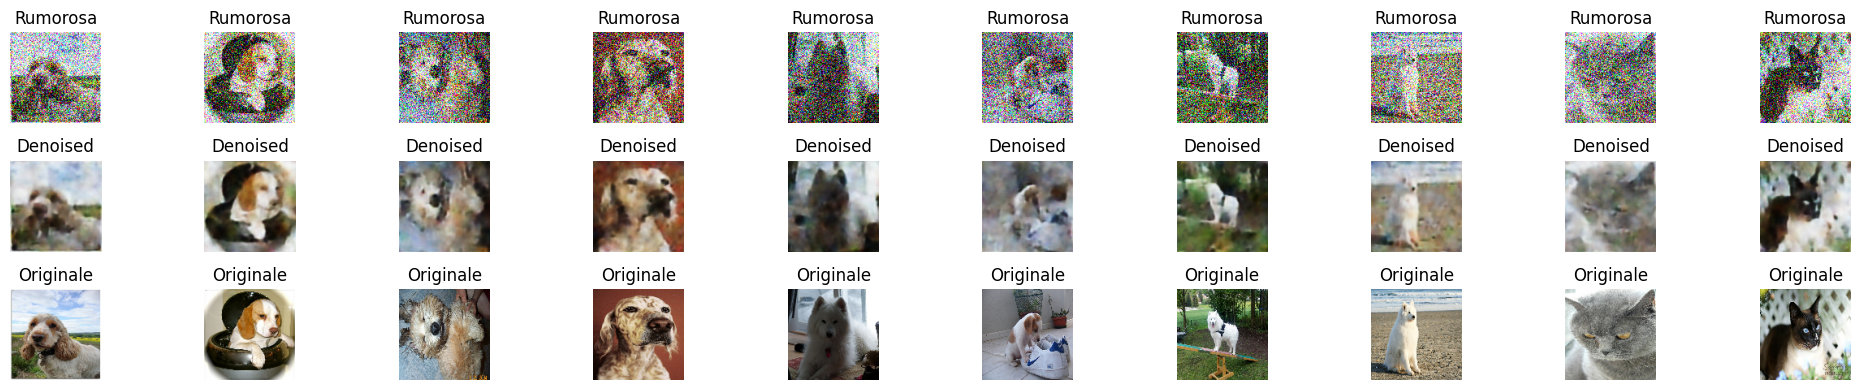

In [181]:
plot_denoising_results(x_noisy_np_test, decoded_imgs, x_original_np_test, n=10)

In [182]:
print(history.history.keys())  # mostra le chiavi disponibili

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [183]:
print(history.history['accuracy'])

[0.5057126879692078, 0.5717301368713379, 0.5453652739524841, 0.5813037753105164, 0.5968391299247742, 0.6078062653541565, 0.6457852721214294, 0.6621571779251099, 0.6656200885772705, 0.687279224395752, 0.692730188369751, 0.708102285861969, 0.7060025334358215, 0.7057276964187622, 0.706922173500061, 0.7154693603515625, 0.7090000510215759, 0.7204691171646118, 0.7089326977729797, 0.7156928777694702, 0.7129783630371094, 0.718000054359436, 0.7188382148742676, 0.7166663408279419, 0.7214711308479309, 0.7202285528182983, 0.7262640595436096, 0.7179588675498962, 0.7200228571891785, 0.7242605686187744, 0.7283846735954285, 0.7282184958457947, 0.7312647700309753, 0.7366179823875427, 0.724591076374054, 0.7278404235839844, 0.7282937169075012, 0.7308087348937988, 0.7351127862930298, 0.7353450059890747, 0.7292863726615906, 0.7396827936172485, 0.7342978119850159, 0.7410534620285034, 0.736702024936676, 0.7356407046318054, 0.7311813235282898, 0.7304527163505554, 0.7417845726013184, 0.7411660552024841]


In [184]:
autoencoder.save('new_autoencoder.keras')

In [185]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(epochs)

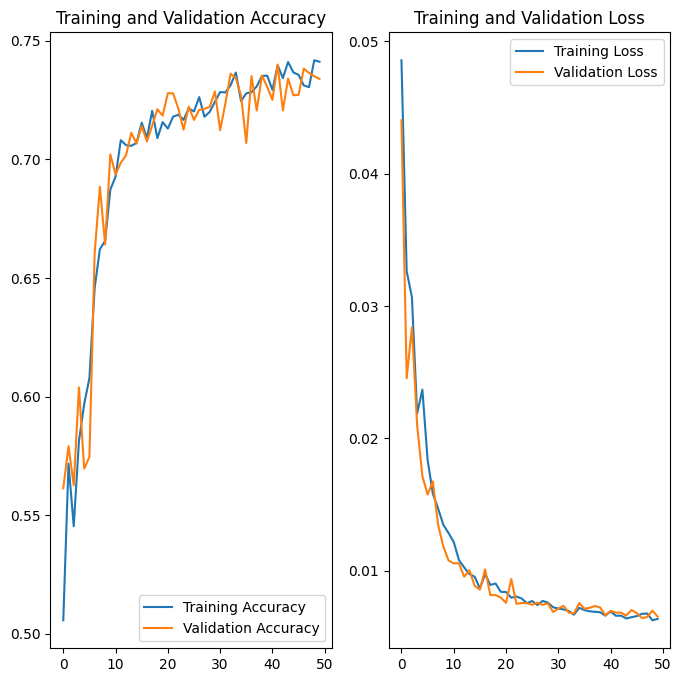

In [186]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [187]:
from skimage.metrics import peak_signal_noise_ratio as psnr

In [188]:
def calculate_psnr(img1, img2):
    """
    Calcola il PSNR tra due immagini TensorFlow (img1 e img2).
    Entrambe devono essere float32 e normalizzate (0-1) o in uint8 (0-255).
    """
    return tf.image.psnr(img1, img2, max_val=1.0 if img1.dtype.is_floating else 255.0).numpy()


In [189]:
from collections import defaultdict

In [190]:
def psnr_by_noise_level(noisy_images, original_images, noise_levels):
    psnr_dict = defaultdict(list)

    for noisy, original, level in zip(noisy_images, original_images, noise_levels):
        psnr = calculate_psnr(tf.convert_to_tensor(noisy), tf.convert_to_tensor(original))
        psnr_dict[level].append(psnr)

    # Calcola media per ogni livello di rumore
    avg_psnr_by_level = {level: np.mean(values) for level, values in psnr_dict.items()}

    return avg_psnr_by_level

In [191]:
noise_levels = [0.1, 0.2, 0.3, 0.4]

In [203]:
def model_psnr_predict(model, original_images, noise_levels = [0.1, 0.2, 0.3, 0.4]):
  all_a_psnr = []
  for level in noise_levels:
    print("Noise level: " + str(level))
    noisy_images = original_images.map(lambda x, label: (add_noise_2(x, level), x))

    batch = next(iter(noisy_images))

    x_noisy_batch, x_original_batch = batch

    noisy_np = x_noisy_batch.numpy()
    original_np = x_original_batch.numpy()

    #Ridnet predict psnr
    decoded = model.predict(noisy_np)
    psnrs = [psnr(original_np[i], decoded[i], data_range=original_np[i].max() - original_np[i].min()) for i in range(len(decoded))]
    all_a_psnr.append(np.mean(psnrs))
    plot_denoising_results(noisy_np, decoded, original_np, n=10)
  print (all_a_psnr)
  return all_a_psnr

Noise level: 0.1
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


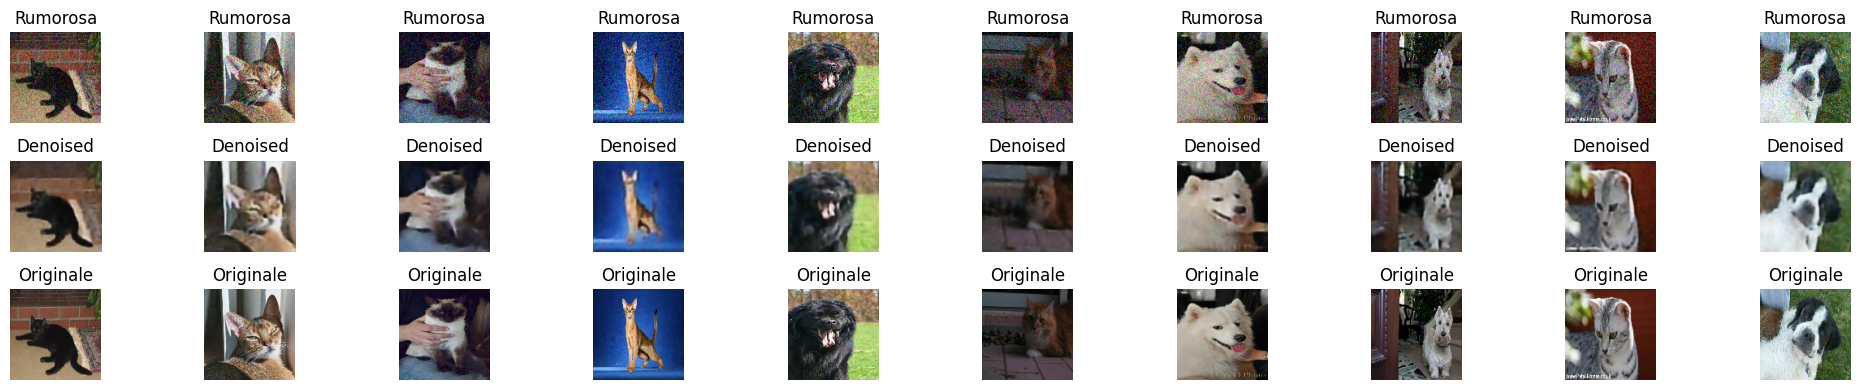

Noise level: 0.2
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


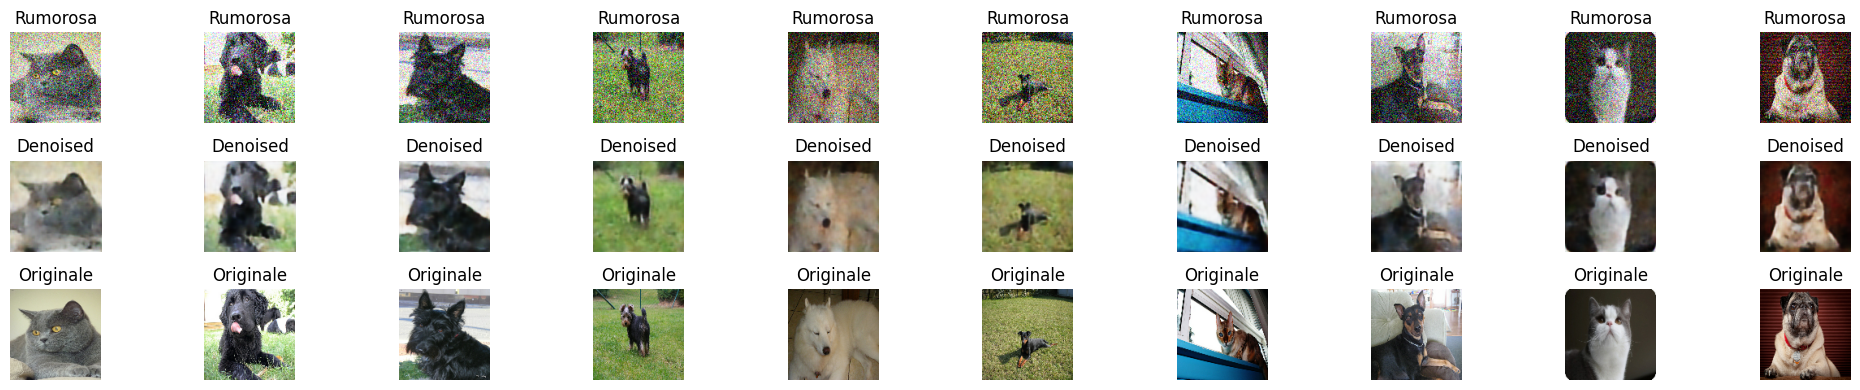

Noise level: 0.3
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


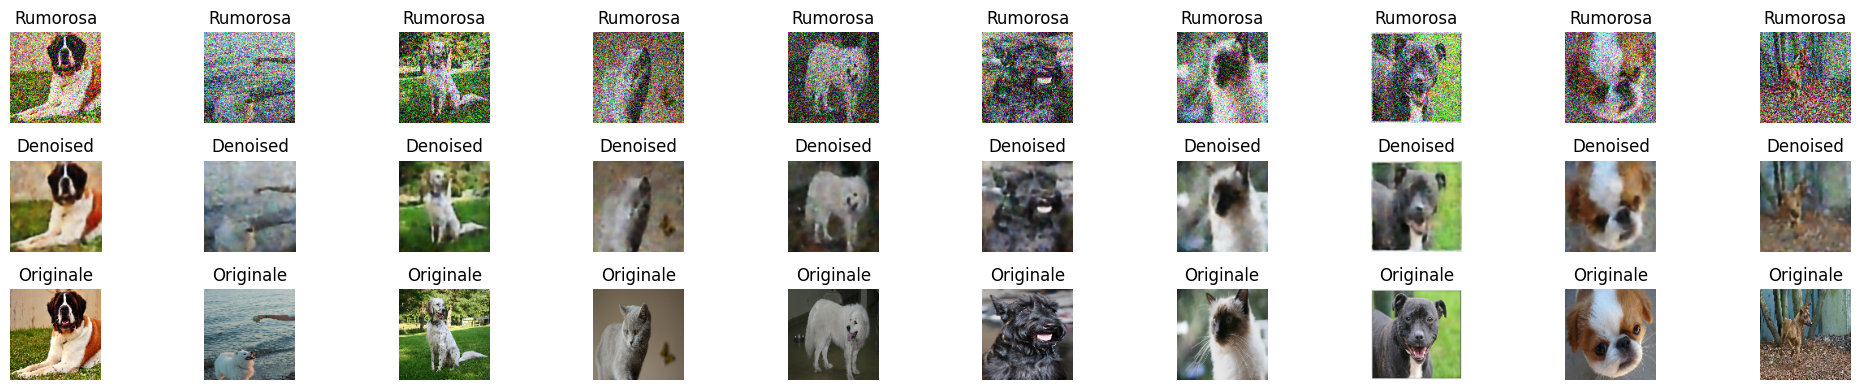

Noise level: 0.4
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


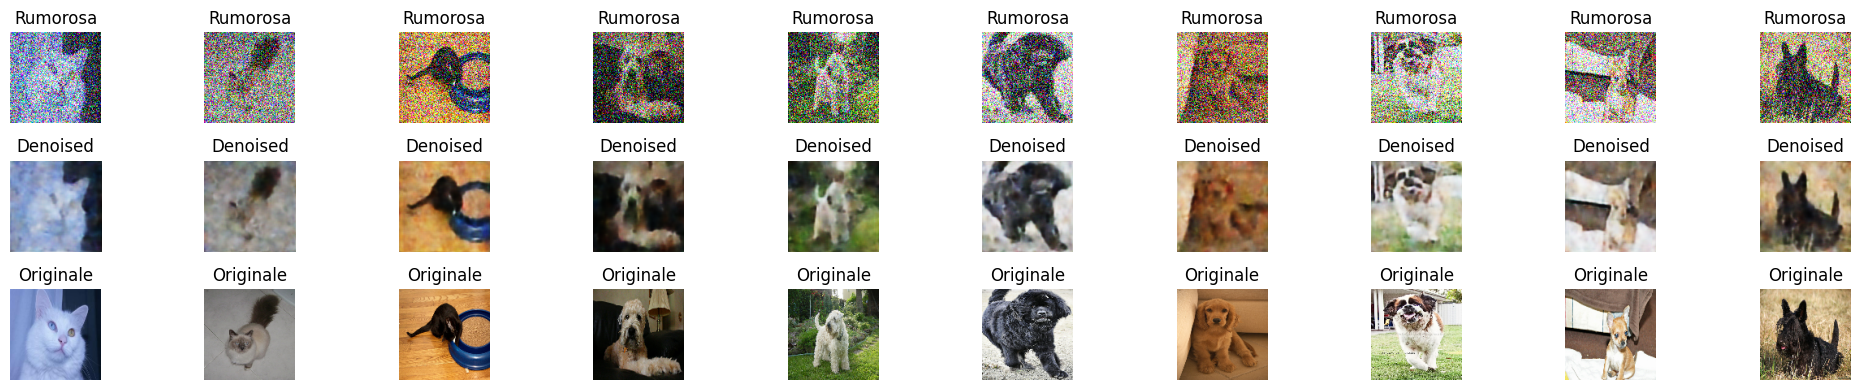

[np.float64(23.703087755246123), np.float64(22.129335150635963), np.float64(21.73812897540147), np.float64(20.76751702075267)]


In [204]:
all_autoen_psnr = model_psnr_predict(autoencoder, test_ds)

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(noise_levels, all_autoen_psnr, marker='o', linestyle='--', color='b')
for x, y in zip(noise_levels, all_autoen_psnr):
    plt.text(x, y - 0.2, f"{y:.2f}", ha='center', va='top', fontsize=9, color='r')

plt.title("PSNR per Noise Level Autoencoder")
plt.xlabel("Noise Factor")
plt.ylabel("PSNR (dB)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [205]:
print(*[f"psnr: {val1}, noise: {val2}" for val1, val2 in zip(all_autoen_psnr, noise_levels)], sep='\n')


psnr: 23.703087755246123, noise: 0.0
psnr: 22.129335150635963, noise: 0.1
psnr: 21.73812897540147, noise: 0.2
psnr: 20.76751702075267, noise: 0.30000000000000004


In [206]:
print(all_autoen_psnr, noise_levels)

[np.float64(23.703087755246123), np.float64(22.129335150635963), np.float64(21.73812897540147), np.float64(20.76751702075267)] [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


In [207]:
def plot_psnr_vs_noise(psnr_dict):
    levels = sorted(psnr_dict.keys())
    psnr_values = [psnr_dict[level] for level in levels]

    plt.figure(figsize=(8, 5))
    plt.plot(levels, psnr_values, marker='o')
    plt.xlabel("Fattore di rumore")
    plt.ylabel("PSNR medio (dB)")
    plt.title("PSNR vs Livello di Rumore")
    plt.grid(True)
    plt.show()

In [208]:
noise_levels = np.linspace(0,1,11)

In [209]:
print(noise_levels)

[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


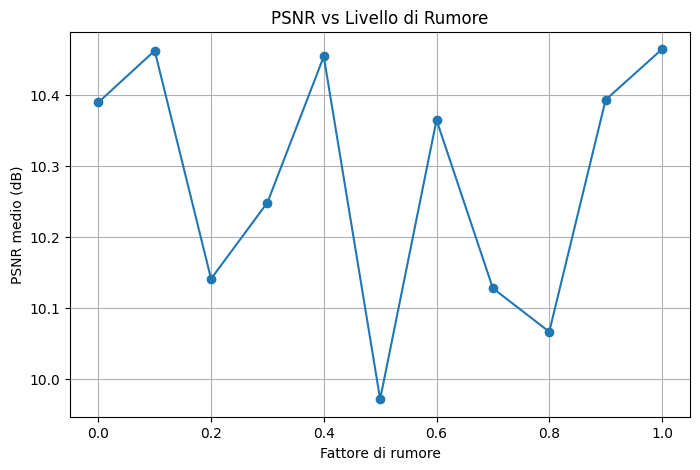

In [210]:
x_noisy_np_test, decoded_imgs, x_original_np_test
avg_psnr = psnr_by_noise_level(x_noisy_np_test, x_original_np_test, noise_levels)
plot_psnr_vs_noise(avg_psnr)


In [211]:
psnr_values = [psnr(x_noisy_np[i], decoded_imgs[i], data_range=1.0) for i in range(len(test_ds_noisy))]


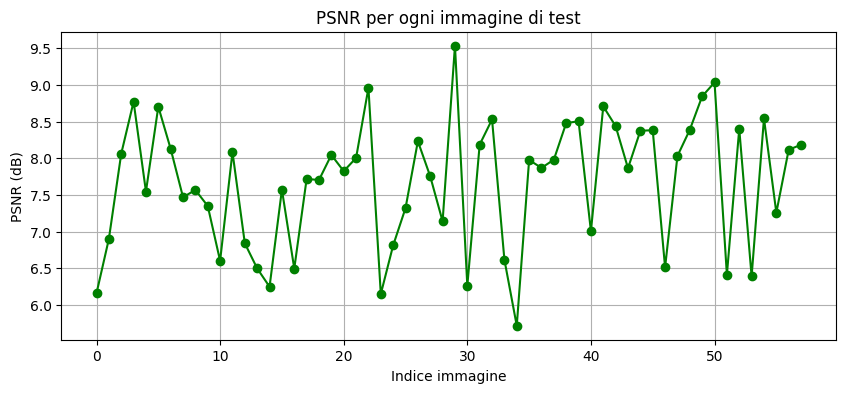

Media PSNR sul test set: 7.68 dB


In [212]:

# Plot dei PSNR per ogni immagine
plt.figure(figsize=(10, 4))
plt.plot(psnr_values, marker='o', linestyle='-', color='green')
plt.title('PSNR per ogni immagine di test')
plt.xlabel('Indice immagine')
plt.ylabel('PSNR (dB)')
plt.grid(True)
plt.show()

# (Facoltativo) Media PSNR
print(f"Media PSNR sul test set: {np.mean(psnr_values):.2f} dB")